In [90]:
%pip install -q gdown

Note: you may need to restart the kernel to use updated packages.


In [91]:
from pathlib import Path
import os, glob, re, warnings
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [92]:
RESULT_DIR = Path("/kaggle/working/descriptive_question_8_outputs")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MIN_VALID_ROWS_PER_FEATURE = 100
MIN_PAIRWISE_ROWS = 50

LOWER_NUMERIC_QUANTILE = 0.005
UPPER_NUMERIC_QUANTILE = 0.995

In [93]:
FOLDER_URL = "https://drive.google.com/drive/folders/1RZJdNpCfbMt2SB_kfWsxQgOk5LeuV7lw"
OUTPUT_ROOT = Path("/kaggle/working")
DATA_DIR = OUTPUT_ROOT / "divar_dataset"
DATA_DIR.mkdir(parents=True, exist_ok=True)

gdown.download_folder(
    url=FOLDER_URL,
    output=str(DATA_DIR),
    quiet=False,
    use_cookies=False
)

csv_files = glob.glob(str(DATA_DIR / "**" / "*.csv"), recursive=True)
if len(csv_files) == 0:
    csv_files = glob.glob(str(OUTPUT_ROOT / "**" / "*.csv"), recursive=True)
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file was found.")

DATA_PATH = max(csv_files, key=os.path.getsize)
DATA_PATH

Retrieving folder contents


Processing file 1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ Divar.csv
Processing file 1eX9an3tSypvrFn_fiPReYHTca5GpJaJG iran_city_classification.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=eb778899-7586-4e7f-b7d4-c30b7d8b4735
To: /kaggle/working/divar_dataset/Divar.csv
100%|██████████| 794M/794M [00:05<00:00, 144MB/s]  
Downloading...
From: https://drive.google.com/uc?id=1eX9an3tSypvrFn_fiPReYHTca5GpJaJG
To: /kaggle/working/divar_dataset/iran_city_classification.csv
100%|██████████| 6.16k/6.16k [00:00<00:00, 8.35MB/s]
Download completed


'/kaggle/working/divar_dataset/Divar.csv'

In [94]:
raw_data = pd.read_csv(DATA_PATH)
raw_data.columns = raw_data.columns.str.strip()
raw_data.shape

(1000000, 61)

In [95]:
PERSIAN_DIGITS = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")
ARABIC_DIGITS = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
BAD_PRICE_TEXT = [
    "توافقی", "مجانی", "رایگان", "صلواتی", "معاوضه", "نامشخص",
    "تماس", "ندارد", "null", "none", "nan", "free", "negotiable"
]
NUMBER_WORDS = {
    "صفر": 0, "یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج": 5,
    "شش": 6, "هفت": 7, "هشت": 8, "نه": 9, "ده": 10
}

def normalize_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    text = text.translate(PERSIAN_DIGITS).translate(ARABIC_DIGITS)
    text = text.replace("ي", "ی").replace("ك", "ک")
    text = re.sub(r"\s+", " ", text)
    return text

def find_column(df, candidates, required=True):
    lookup = {c.lower().strip(): c for c in df.columns}
    for candidate in candidates:
        key = candidate.lower().strip()
        if key in lookup:
            return lookup[key]
    if required:
        raise ValueError(f"None of these columns were found: {candidates}")
    return None

def clean_numeric(series):
    text = (
        series.astype("string").map(normalize_text).astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("٬", "", regex=False)
        .str.replace("،", "", regex=False)
        .str.replace("تومان", "", regex=False)
        .str.replace("ریال", "", regex=False)
        .str.replace("متر", "", regex=False)
        .str.replace("نفر", "", regex=False)
    )
    words = text.map(lambda x: NUMBER_WORDS.get(str(x).strip(), np.nan))
    extracted = text.str.extract(r"([-+]?\d*\.?\d+)", expand=False)
    return pd.to_numeric(extracted, errors="coerce").fillna(words)

def clean_price(series):
    text = series.astype("string").map(normalize_text).astype("string")
    bad_mask = text.str.lower().fillna("").str.contains("|".join(BAD_PRICE_TEXT), regex=True)
    values = clean_numeric(text)
    values[bad_mask] = np.nan
    return values

def save_table(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, encoding="utf-8-sig")
    return path

def set_plot_style(grid=True):
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#1F2937",
        "axes.linewidth": 0.9,
        "axes.grid": grid,
        "grid.color": "#E5E7EB",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.70,
        "axes.axisbelow": True,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

In [96]:
def set_out_of_range_to_nan(series, lower=None, upper=None):
    result = series.copy()
    if lower is not None:
        result = result.mask(result < lower)
    if upper is not None:
        result = result.mask(result > upper)
    return result

def winsorize_series(series, lower_q=0.005, upper_q=0.995):
    result = series.copy()
    non_missing = result.dropna()
    if len(non_missing) < 100:
        return result, np.nan, np.nan
    lower = non_missing.quantile(lower_q)
    upper = non_missing.quantile(upper_q)
    return result.clip(lower=lower, upper=upper), float(lower), float(upper)

def pairwise_counts(df):
    valid = df.notna().astype(int)
    return valid.T @ valid

def plot_corr(corr, title, label, path):
    set_plot_style(grid=False)
    fig, ax = plt.subplots(figsize=(11, 8.5))

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad("#F3F4F6")

    values = np.ma.masked_invalid(corr.to_numpy(dtype=float))
    image = ax.imshow(values, cmap=cmap, vmin=-1, vmax=1)

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)

    raw = corr.to_numpy(dtype=float)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = raw[i, j]
            if np.isnan(value):
                text, color = "NA", "#6B7280"
            else:
                text = f"{value:.2f}"
                color = "white" if abs(value) >= 0.55 else "#111827"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)

    cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label, rotation=270, labelpad=16)

    ax.set_title(title, pad=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()
    return path

def top_correlations(corr, top_n=12):
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack(dropna=True)
        .reset_index()
    )
    pairs.columns = ["feature_1", "feature_2", "correlation"]
    pairs["abs_correlation"] = pairs["correlation"].abs()
    return pairs.sort_values("abs_correlation", ascending=False).head(top_n).reset_index(drop=True)

In [97]:
price_col = find_column(
    raw_data,
    ["price_transformable", "price_value", "value_price", "price", "sale_price", "total_price"],
    required=True
)
land_col = find_column(raw_data, ["land_size", "size_land", "land_area", "area_land"], required=False)
building_col = find_column(raw_data, ["building_size", "size_building", "building_area", "area_building", "area"], required=False)
capacity_col = find_column(raw_data, ["regular_person_capacity", "person_capacity", "capacity_person_regular", "capacity"], required=False)
rooms_col = find_column(raw_data, ["rooms_count", "count_rooms", "room_count", "rooms"], required=False)
lat_col = find_column(raw_data, ["location_latitude", "latitude_location", "latitude", "lat"], required=True)
lon_col = find_column(raw_data, ["location_longitude", "longitude_location", "longitude", "lon", "lng"], required=True)

resolved_columns = {
    "price_col": price_col,
    "land_col": land_col,
    "building_col": building_col,
    "capacity_col": capacity_col,
    "rooms_col": rooms_col,
    "lat_col": lat_col,
    "lon_col": lon_col
}
resolved_columns

{'price_col': 'price_value',
 'land_col': 'land_size',
 'building_col': 'building_size',
 'capacity_col': 'regular_person_capacity',
 'rooms_col': 'rooms_count',
 'lat_col': 'location_latitude',
 'lon_col': 'location_longitude'}

In [98]:
source_columns = {
    "price": price_col,
    "land_size": land_col,
    "building_size": building_col,
    "regular_person_capacity": capacity_col,
    "rooms_count": rooms_col,
    "latitude": lat_col,
    "longitude": lon_col
}

source_columns = {k: v for k, v in source_columns.items() if v is not None}

analysis_data = pd.DataFrame(index=raw_data.index)

for clean_name, source_name in source_columns.items():
    if clean_name == "price":
        analysis_data[clean_name] = clean_price(raw_data[source_name])
    else:
        analysis_data[clean_name] = clean_numeric(raw_data[source_name])

initial_rows = len(analysis_data)
analysis_data = analysis_data[analysis_data["price"].notna()].copy()
after_numeric_price = len(analysis_data)
analysis_data = analysis_data[analysis_data["price"] > 0].copy()
after_positive_price = len(analysis_data)

assert (analysis_data["price"] > 0).all()

price_audit = pd.DataFrame([
    {
        "initial_rows": initial_rows,
        "rows_after_numeric_price": after_numeric_price,
        "rows_after_strict_positive_price": after_positive_price,
        "removed_missing_or_non_numeric_price": initial_rows - after_numeric_price,
        "removed_zero_or_negative_price": after_numeric_price - after_positive_price
    }
])

display(price_audit)
analysis_data.shape

,initial_rows,rows_after_numeric_price,rows_after_strict_positive_price,removed_missing_or_non_numeric_price,removed_zero_or_negative_price
0,1000000,568346,566444,431654,1902


(566444, 7)

In [99]:
quality_data = analysis_data.copy()

if "land_size" in quality_data.columns:
    quality_data["land_size"] = set_out_of_range_to_nan(quality_data["land_size"], 1, 100000)

if "building_size" in quality_data.columns:
    quality_data["building_size"] = set_out_of_range_to_nan(quality_data["building_size"], 1, 100000)

if "regular_person_capacity" in quality_data.columns:
    quality_data["regular_person_capacity"] = set_out_of_range_to_nan(quality_data["regular_person_capacity"], 0, 100)

if "rooms_count" in quality_data.columns:
    quality_data["rooms_count"] = set_out_of_range_to_nan(quality_data["rooms_count"], 0, 20)

if "latitude" in quality_data.columns:
    quality_data["latitude"] = set_out_of_range_to_nan(quality_data["latitude"], 24, 40)

if "longitude" in quality_data.columns:
    quality_data["longitude"] = set_out_of_range_to_nan(quality_data["longitude"], 43, 64)

winsor_rows = []
for col in ["price", "land_size", "building_size", "regular_person_capacity", "rooms_count"]:
    if col in quality_data.columns:
        quality_data[col], lower, upper = winsorize_series(
            quality_data[col],
            lower_q=LOWER_NUMERIC_QUANTILE,
            upper_q=UPPER_NUMERIC_QUANTILE
        )
        winsor_rows.append({"column": col, "lower_bound": lower, "upper_bound": upper})

quality_data = quality_data[quality_data["price"] > 0].copy()
quality_data["log_price"] = np.log1p(quality_data["price"])

if "land_size" in quality_data.columns:
    quality_data["log_land_size"] = np.log1p(quality_data["land_size"])

if "building_size" in quality_data.columns:
    quality_data["log_building_size"] = np.log1p(quality_data["building_size"])

assert (quality_data["price"] > 0).all()
assert (quality_data["log_price"] > 0).all()

winsor_audit = pd.DataFrame(winsor_rows)
display(winsor_audit)
quality_data.shape

,column,lower_bound,upper_bound
0,price,1111.0,1.300000e+11
1,land_size,40.0,4.704500e+03
2,building_size,10.0,1.100000e+04
3,regular_person_capacity,NaN,NaN
4,rooms_count,1.0,4.000000e+00


(566444, 10)

In [100]:
missing_summary = pd.DataFrame(
    {
        "non_missing_count": quality_data.notna().sum(),
        "missing_count": quality_data.isna().sum(),
        "missing_ratio": quality_data.isna().mean(),
        "unique_count": quality_data.nunique(dropna=True)
    }
).sort_values("missing_ratio", ascending=False)

descriptive_summary = quality_data.describe().T

display(missing_summary.round(4))
display(descriptive_summary.round(3))

,non_missing_count,missing_count,missing_ratio,unique_count
regular_person_capacity,0,566444,1.0000,0
land_size,120365,446079,0.7875,1310
log_land_size,120365,446079,0.7875,1310
latitude,370908,195536,0.3452,252492
longitude,370913,195531,0.3452,277191
rooms_count,423157,143287,0.2530,4
log_building_size,563972,2472,0.0044,2447
building_size,563972,2472,0.0044,2447
price,566444,0,0.0000,12039
log_price,566444,0,0.0000,12039


,count,mean,std,min,25%,50%,75%,max
price,566444.0,6456109238.512,13994095296.319,1111.0,1410000000.0,2850000000.0,5923500000.0,130000000000.0
land_size,120365.0,331.827,490.366,40.0,130.0,200.0,310.0,4704.5
building_size,563972.0,301.537,1026.22,10.0,79.0,110.0,184.0,11000.0
regular_person_capacity,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
rooms_count,423157.0,2.054,0.734,1.0,2.0,2.0,2.0,4.0
latitude,370908.0,35.073,2.324,24.592,34.677,35.726,36.351,39.773
longitude,370913.0,51.552,3.107,43.136,50.565,51.329,51.835,62.708
log_price,566444.0,21.599,1.992,7.014,21.067,21.771,22.502,25.591
log_land_size,120365.0,5.402,0.796,3.714,4.875,5.303,5.74,8.456
log_building_size,563972.0,4.889,0.929,2.398,4.382,4.71,5.22,9.306


In [101]:
preferred_columns = [
    "log_price",
    "price",
    "log_land_size",
    "land_size",
    "log_building_size",
    "building_size",
    "regular_person_capacity",
    "rooms_count",
    "latitude",
    "longitude"
]

candidate_columns = [col for col in preferred_columns if col in quality_data.columns]

usable_columns = []
for col in candidate_columns:
    non_missing = quality_data[col].notna().sum()
    unique_count = quality_data[col].nunique(dropna=True)
    if non_missing >= MIN_VALID_ROWS_PER_FEATURE and unique_count > 1:
        usable_columns.append(col)

if len(usable_columns) < 2:
    raise ValueError("Not enough usable numeric columns for correlation analysis.")

matrix_data = quality_data[usable_columns].copy()
valid_pair_counts = pairwise_counts(matrix_data)

min_pairwise_rows = min(
    MIN_PAIRWISE_ROWS,
    max(10, int(matrix_data.notna().sum().max() * 0.01))
)

display(pd.DataFrame({"selected_features": usable_columns}))
display(valid_pair_counts)

min_pairwise_rows

,selected_features
0,log_price
1,price
2,log_land_size
3,land_size
4,log_building_size
5,building_size
6,rooms_count
7,latitude
8,longitude


,log_price,price,log_land_size,land_size,log_building_size,building_size,rooms_count,latitude,longitude
log_price,566444,566444,120365,120365,563972,563972,423157,370908,370913
price,566444,566444,120365,120365,563972,563972,423157,370908,370913
log_land_size,120365,120365,120365,120365,120147,120147,109886,73868,73868
land_size,120365,120365,120365,120365,120147,120147,109886,73868,73868
log_building_size,563972,563972,120147,120147,563972,563972,422638,369500,369505
building_size,563972,563972,120147,120147,563972,563972,422638,369500,369505
rooms_count,423157,423157,109886,109886,422638,422638,423157,279229,279235
latitude,370908,370908,73868,73868,369500,369500,279229,370908,370906
longitude,370913,370913,73868,73868,369505,369505,279235,370906,370913


50

In [102]:
pearson_corr = matrix_data.corr(method="pearson", min_periods=min_pairwise_rows)
pearson_corr.round(3)

,log_price,price,log_land_size,land_size,log_building_size,building_size,rooms_count,latitude,longitude
log_price,1.000,0.440,0.080,0.011,0.080,0.020,0.214,0.053,-0.005
price,0.440,1.000,0.213,0.161,0.227,0.139,0.293,0.021,-0.003
log_land_size,0.080,0.213,1.000,0.781,0.280,0.216,0.204,0.042,0.038
land_size,0.011,0.161,0.781,1.000,0.143,0.289,0.009,0.024,-0.008
log_building_size,0.080,0.227,0.280,0.143,1.000,0.679,0.599,-0.062,0.005
building_size,0.020,0.139,0.216,0.289,0.679,1.000,0.077,-0.014,-0.022
rooms_count,0.214,0.293,0.204,0.009,0.599,0.077,1.000,-0.059,0.048
latitude,0.053,0.021,0.042,0.024,-0.062,-0.014,-0.059,1.000,-0.223
longitude,-0.005,-0.003,0.038,-0.008,0.005,-0.022,0.048,-0.223,1.000


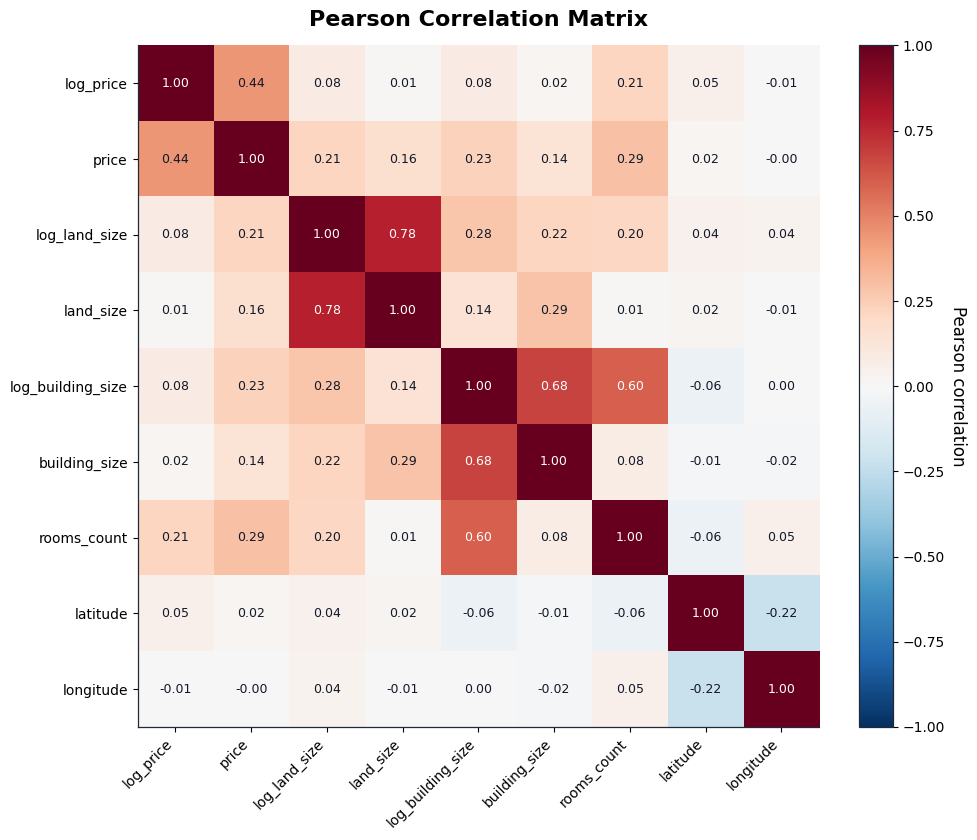

PosixPath('/kaggle/working/descriptive_question_8_outputs/question_8_pearson_correlation_heatmap.png')

In [103]:
pearson_path = plot_corr(
    pearson_corr,
    "Pearson Correlation Matrix",
    "Pearson correlation",
    RESULT_DIR / "question_8_pearson_correlation_heatmap.png"
)
pearson_path

In [104]:
spearman_corr = matrix_data.corr(method="spearman", min_periods=min_pairwise_rows)
spearman_corr.round(3)

,log_price,price,log_land_size,land_size,log_building_size,building_size,rooms_count,latitude,longitude
log_price,1.000,1.000,0.280,0.280,0.191,0.191,0.429,0.026,0.064
price,1.000,1.000,0.280,0.280,0.191,0.191,0.429,0.026,0.064
log_land_size,0.280,0.280,1.000,1.000,0.367,0.367,0.288,0.106,0.089
land_size,0.280,0.280,1.000,1.000,0.367,0.367,0.288,0.106,0.089
log_building_size,0.191,0.191,0.367,0.367,1.000,1.000,0.726,0.039,0.042
building_size,0.191,0.191,0.367,0.367,1.000,1.000,0.726,0.039,0.042
rooms_count,0.429,0.429,0.288,0.288,0.726,0.726,1.000,0.079,0.082
latitude,0.026,0.026,0.106,0.106,0.039,0.039,0.079,1.000,-0.162
longitude,0.064,0.064,0.089,0.089,0.042,0.042,0.082,-0.162,1.000


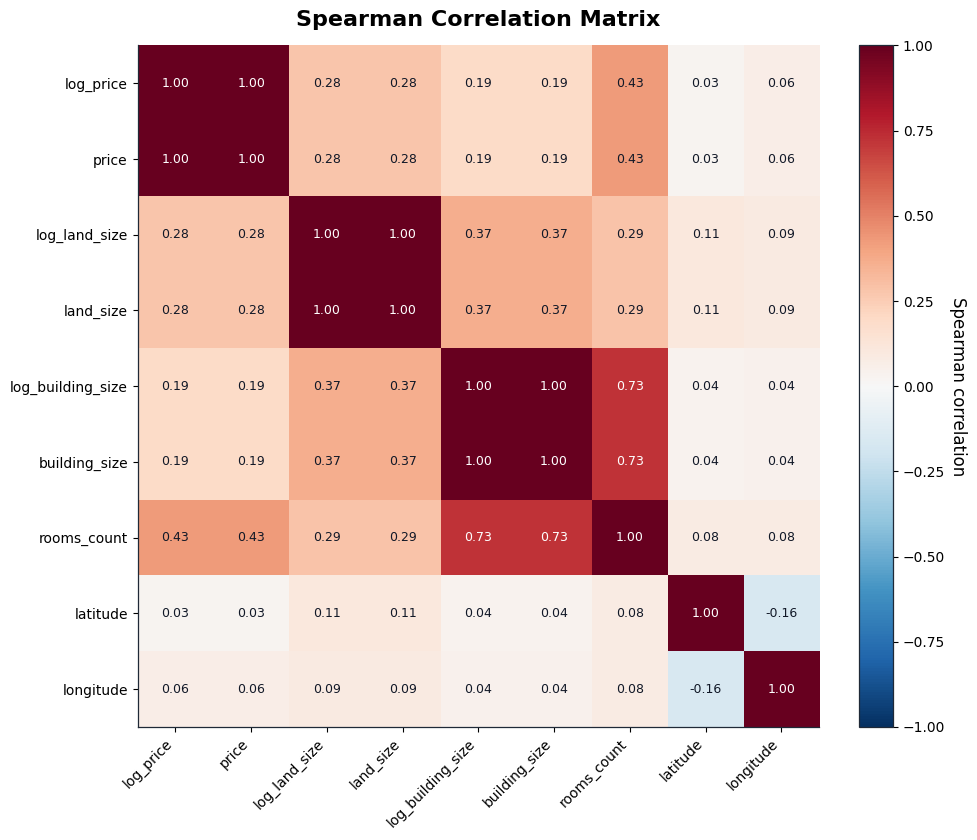

PosixPath('/kaggle/working/descriptive_question_8_outputs/question_8_spearman_correlation_heatmap.png')

In [105]:
spearman_path = plot_corr(
    spearman_corr,
    "Spearman Correlation Matrix",
    "Spearman correlation",
    RESULT_DIR / "question_8_spearman_correlation_heatmap.png"
)
spearman_path

In [106]:
top_pearson = top_correlations(pearson_corr, top_n=12)
top_spearman = top_correlations(spearman_corr, top_n=12)

print("Top Pearson correlations")
display(top_pearson.round(3))

print("Top Spearman correlations")
display(top_spearman.round(3))

Top Pearson correlations


,feature_1,feature_2,correlation,abs_correlation
0,log_land_size,land_size,0.781,0.781
1,log_building_size,building_size,0.679,0.679
2,log_building_size,rooms_count,0.599,0.599
3,log_price,price,0.440,0.440
4,price,rooms_count,0.293,0.293
5,land_size,building_size,0.289,0.289
6,log_land_size,log_building_size,0.280,0.280
7,price,log_building_size,0.227,0.227
8,latitude,longitude,-0.223,0.223
9,log_land_size,building_size,0.216,0.216


Top Spearman correlations


,feature_1,feature_2,correlation,abs_correlation
0,log_price,price,1.000,1.000
1,log_land_size,land_size,1.000,1.000
2,log_building_size,building_size,1.000,1.000
3,log_building_size,rooms_count,0.726,0.726
4,building_size,rooms_count,0.726,0.726
5,price,rooms_count,0.429,0.429
6,log_price,rooms_count,0.429,0.429
7,log_land_size,log_building_size,0.367,0.367
8,land_size,log_building_size,0.367,0.367
9,land_size,building_size,0.367,0.367


In [107]:
print("Question 8 interpretation")
print("-" * 70)

if "log_price" in pearson_corr.columns:
    pearson_links = (
        pearson_corr["log_price"]
        .drop("log_price")
        .dropna()
        .sort_values(key=lambda values: values.abs(), ascending=False)
    )
    print("Strongest Pearson correlations with log_price:")
    display(pearson_links.round(3))

if "log_price" in spearman_corr.columns:
    spearman_links = (
        spearman_corr["log_price"]
        .drop("log_price")
        .dropna()
        .sort_values(key=lambda values: values.abs(), ascending=False)
    )
    print("Strongest Spearman correlations with log_price:")
    display(spearman_links.round(3))

print(
    "All analyzed prices are strictly positive. "
    "Pairwise-valid correlation prevents missing values in one variable from removing the row from every other correlation pair."
)

Question 8 interpretation
----------------------------------------------------------------------
Strongest Pearson correlations with log_price:


price                0.440
rooms_count          0.214
log_building_size    0.080
log_land_size        0.080
latitude             0.053
building_size        0.020
land_size            0.011
longitude           -0.005
Name: log_price, dtype: float64

Strongest Spearman correlations with log_price:


price                1.000
rooms_count          0.429
land_size            0.280
log_land_size        0.280
log_building_size    0.191
building_size        0.191
longitude            0.064
latitude             0.026
Name: log_price, dtype: float64

All analyzed prices are strictly positive. Pairwise-valid correlation prevents missing values in one variable from removing the row from every other correlation pair.


In [108]:
save_table(price_audit, RESULT_DIR / "question_8_price_cleaning_audit.csv")
save_table(winsor_audit, RESULT_DIR / "question_8_winsorization_audit.csv")
save_table(missing_summary, RESULT_DIR / "question_8_missing_summary.csv")
save_table(descriptive_summary, RESULT_DIR / "question_8_descriptive_summary.csv")
save_table(valid_pair_counts, RESULT_DIR / "question_8_pairwise_valid_counts.csv")
save_table(pearson_corr, RESULT_DIR / "question_8_pearson_correlation.csv")
save_table(spearman_corr, RESULT_DIR / "question_8_spearman_correlation.csv")
save_table(top_pearson, RESULT_DIR / "question_8_top_pearson_correlations.csv")
save_table(top_spearman, RESULT_DIR / "question_8_top_spearman_correlations.csv")

matrix_data.sample(
    n=min(10000, len(matrix_data)),
    random_state=RANDOM_STATE
).to_csv(
    RESULT_DIR / "question_8_clean_correlation_data_sample.csv",
    index=False,
    encoding="utf-8-sig"
)

RESULT_DIR

PosixPath('/kaggle/working/descriptive_question_8_outputs')